In [1]:
%load_ext autoreload
%autoreload 2

import os
os.chdir("C:/Users/Administrator/PythonProjects/abfluss_queich")

In [2]:
import pandas as pd

import matplotlib.pyplot as plt

### Discharge

In [3]:
from database.queries import load_discharge_data

from jobs.discharge.preprocessing.filtering import hampel_filter
from jobs.discharge.ingest_discharge import write_to_db

In [4]:
discharge_path = "data/discharge_siebeldingen_2026-0514.csv"

def read_discharge(path: str) -> pd.Series:
    
    df = pd.read_csv(path, sep=";", na_values="-")
        
    df["discharge"] = df["discharge"].str.replace(",", ".").astype("float")

    df["timestamp"] =  pd.to_datetime(df["timestamp"], format="%d.%m.%Y %H:%M")

    df = df.set_index(keys="timestamp")
    df = df.sort_index()
    
    df = hampel_filter(series=df)
    
    df = df.dropna(subset=["discharge"])
    
    return df

discharge = read_discharge(path=discharge_path)

In [5]:
discharge_db = load_discharge_data(days=90)
discharge_db = hampel_filter(series=discharge_db)

In [6]:
discharge_db.head()

,discharge
timestamp,
2026-03-11 13:00:00,1.642
2026-03-11 13:15:00,1.642
2026-03-11 13:30:00,1.642
2026-03-11 13:45:00,1.642
2026-03-11 14:00:00,1.642


In [7]:
discharge_diff = discharge.loc[
    ~discharge.index.isin(discharge_db.index)
]

discharge_diff = discharge_diff.drop(discharge_diff.iloc[-2:].index)

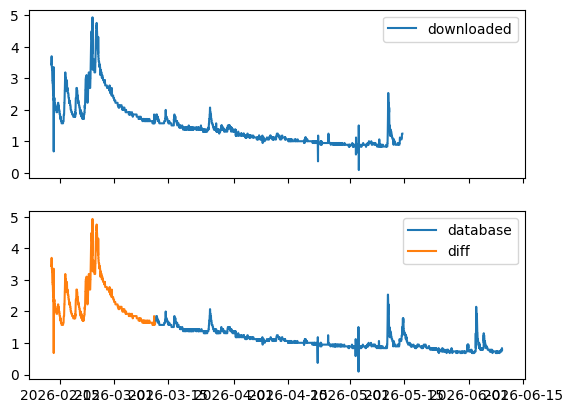

In [8]:
fig, axs = plt.subplots(nrows=2, sharex=True)

axs[0].plot(discharge, label="downloaded")
axs[1].plot(discharge_db, label="database")
axs[1].plot(discharge_diff, label="diff")

axs[0].legend()
axs[1].legend()
axs[1].legend()

plt.show()

In [83]:
from sqlalchemy.orm import Session

from database.db import SessionLocal
from database.models import Discharge

from utils.logger import logger


def write_to_db(df) -> bool:
    session: Session = SessionLocal()

    try:
        # last_timestamp = get_last_timestamp(session)
        
        # if last_timestamp is not None:
        #     df = df[df.index > last_timestamp]
        
        if df.empty:
            logger.info("No new data.")
            
            return False


        entries = [
            Discharge(
                timestamp=timestamp,
                discharge=row["discharge"],
            )
            for timestamp, row in df.iterrows()
        ]

        session.add_all(entries)
        session.commit()
        
        logger.info("[DISCHARGE] Inserted %s rows.", len(df))

        return True
        
        
    except Exception:
        session.rollback()
        logger.exception("[DISCHARGE] Failed DB ingestion.")
        return False


    finally:
        session.close()

In [116]:
write_to_db(df=discharge_diff)

2026-06-09 12:24:57,251 | 3036016799.py | INFO | [DISCHARGE] Inserted 5745 rows.


True

<Axes: xlabel='timestamp'>

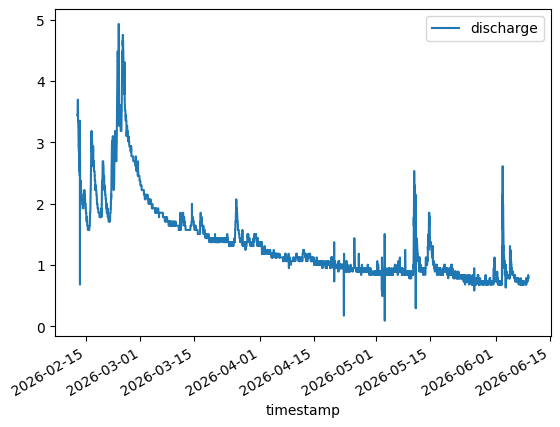

In [9]:
discharge_db_new = load_discharge_data(days=120)
discharge_db_new.plot()

In [12]:
latest_discharge_ts = discharge_db_new.index.min()
latest_discharge_ts

Timestamp('2026-02-12 16:45:00')

### RADOLAN

In [13]:
from database.queries import load_precip_hourly_observation_data

In [14]:
from pathlib import Path
from urllib.parse import urljoin
import requests
from bs4 import BeautifulSoup, Tag
import pandas as pd

from configs import settings
from utils.logger import logger 


radolan_settings = settings.ingestion.radolan_hourly


def get_upload_time(html_tag: Tag) -> pd.Timestamp | None:

    tail = str(html_tag.next_sibling)
    
    if tail is None:
        return None
    
    parts = tail.strip().split()
    
    upload_time = pd.to_datetime(
        f"{parts[0]} {parts[1]}",
        dayfirst=True
    )
    
    return upload_time


def get_observation_date(href: str) -> pd.Timestamp:
    
    _, _, date, _ = href.split("-", maxsplit=3)
    
    return pd.to_datetime(date, format="%y%m%d%H%M")


def fetch_radolan_metadata(url: str | Path) -> pd.DataFrame:
    try:
        response = requests.get(str(url), timeout=30)
        response.raise_for_status()

        soup = BeautifulSoup(response.text, "html.parser")
        
        
        rows = []

        for a in soup.find_all("a"):

            # Get filename
            href = str(a.get("href"))
            
            if not href:
                continue

            if not href.endswith(".gz"):
                continue
            
            
            observation_date = get_observation_date(href=href)
            upload_time = get_upload_time(html_tag=a)
            
            if upload_time is None:
                continue
            
            # if upload_time < pd.Timestamp.now() - pd.DateOffset(days=10):
            if upload_time < latest_discharge_ts:
                continue    
            
            
            rows.append({
                        "filename": href,
                        "datetime_observation": observation_date,
                        "datetime_upload": upload_time,
                    })

        return pd.DataFrame(rows)
        
        
    except requests.RequestException as e:
        logger.exception("Failed to fetch icon metadata from %s", url)
        raise
    

def get_local_observation_date(directory: str | Path):
    directory = Path(directory)
    
    observation_dates = set()
    
    for file in directory.glob("*.gz"):
        observation_date = get_observation_date(href=file.name)
        
        observation_dates.add(observation_date)
        
    return observation_dates


def download_radolan_file(
    root_url: str,
    file_name: str,
    output_dir: str
    ) -> None:
    
    file_url = urljoin(root_url, file_name)

    output_path = Path(output_dir) / file_name
    output_path.parent.mkdir(parents=True, exist_ok=True)
    
    if output_path.exists():
        logger.info("File %s yet exists, skip download", file_name)
        return
        
    try:
        logger.info("Downloading %s", file_name)    
        
        with requests.get(file_url, timeout=30, stream=True) as r:
                    
            r.raise_for_status()

            with open(output_path, "wb") as f:
                for chunk in r.iter_content(chunk_size=8192):
                    f.write(chunk)
        
        logger.info("Saved file to %s", output_path)
        
        
    except requests.RequestException:
        logger.exception("Failed downloading file: %s", file_url)
        raise
    
    except OSError:
        logger.exception("Failed writing file: %s", output_path)
        raise
    
    
    
def fetch_radolan() -> None:
    
    df_remote = fetch_radolan_metadata(url=radolan_settings.url)
    local_times = get_local_observation_date(directory=radolan_settings.compressed_dir)

    df_missing = df_remote[
        ~df_remote["datetime_observation"].isin(local_times)
    ]

    logger.info("Found %s new precip observation files", len(df_missing))
    
    files = 0
    for _, row in df_missing.iterrows():

        download_radolan_file(
            root_url=radolan_settings.url,
            file_name=row["filename"],
            output_dir=radolan_settings.compressed_dir,
        )
        
        files += 1

    logger.info("Downloaded %s new precip observation files", files)


In [15]:
from tqdm import tqdm
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd

import wradlib as wrl
import xarray as xr
import rioxarray

from configs import settings
from utils.logger import logger


def read_radolan_data(
    file_path: str | Path
    ) -> tuple[np.ndarray, dict]:
    
    file_path = str(file_path)
    
    try:
        data, attrs = wrl.io.read_radolan_composite(file_path)
        
        data = np.array(data).astype(float)
        data = np.where(data == -9999, np.nan, data)
    
    except Exception:
        logger.exception("Failed to open RADOLAN BIN file: %s", file_path)
        raise
        
    return data, attrs


def get_observation_date(href: str) -> pd.Timestamp:
    
    _, _, date, _ = href.split("-", maxsplit=3)
    
    return pd.to_datetime(date, format="%y%m%d%H%M")


def extract_radolan_timestamp(
    file_path: str | Path
    ) -> pd.Timestamp:
    
    stem = Path(file_path).stem
    
    _, _, timestring, _ = stem.split("-", maxsplit=3)
    
    observation_time = pd.to_datetime(timestring, format="%y%m%d%H%M")
    
    return observation_time


def extract_radolan_coords(
    attrs: dict
    ) -> tuple[np.ndarray, np.ndarray]:
    
    grid = wrl.georef.get_radolan_grid(
        attrs["nrow"],
        attrs["ncol"]
    )
    
    x2d = np.array(grid)[:, :, 0]
    y2d = np.array(grid)[:, :, 1]
    
    return x2d, y2d


def radolan_to_xarray(
    file_path: str | Path
    ) -> xr.DataArray:
    
    data, attrs = read_radolan_data(file_path=file_path)
    
    observation_time = extract_radolan_timestamp(file_path=file_path)
    
    x2d, y2d = extract_radolan_coords(attrs=attrs)
    
    
    data_xr = xr.DataArray(
        data[np.newaxis, :, :],
        dims=("time", "y", "x"),
        coords={
            "time": [observation_time],
            "x": x2d[0, :],
            "y": y2d[:, 0],
            },
        name="precip"
        )
    
    data_xr = data_xr.rio.set_spatial_dims(x_dim="x", y_dim="y")
    data_xr = data_xr.rio.write_crs(wrl.georef.projection.create_crs("dwd-radolan"))
        

    return data_xr


def clip_to_catchment(
    dataset: xr.DataArray,
    catchment: gpd.GeoDataFrame,
    ) -> xr.DataArray:
    
    precip = dataset
    
    # Check CRS
    catchment = catchment.to_crs(dataset.rio.crs)
    
    
     # --- Crop bounding box of catchment ---
    minx, miny, maxx, maxy = catchment.total_bounds

    precip_crop = precip.rio.clip_box(
        minx=minx,
        miny=miny,
        maxx=maxx,
        maxy=maxy,
    )
    
    # # --- Optional geometry clip ---
    # precip_crop = precip.rio.clip(
    #     catchment.geometry,
    #     # catchment.crs,
    #     drop=False,
    # )
    
    return precip_crop  


def extract_precip_timeseries(
    file_path: str | Path,
    catchment: gpd.GeoDataFrame,
    ) -> dict:
    
    data_xr = radolan_to_xarray(file_path=file_path)
    
    precip_clipped = clip_to_catchment(
        dataset=data_xr,
        catchment=catchment,
        )

    observed_time = pd.to_datetime(precip_clipped.time.item())
    precip_mean = float(precip_clipped.mean(skipna=True)) 

    row = {
        "timestamp": observed_time,
        "precip_mean": precip_mean
        }
    
    return row


def resample_precip(df: pd.DataFrame) -> pd.DataFrame:
    
    df_10min = df.copy()

    df_10min.index = df_10min.index - pd.Timedelta(minutes=10)

    df_1min = (
        df_10min / 10
        ).reindex(
            pd.date_range(
                df_10min.index[0],
                df_10min.index[-1] + pd.Timedelta(minutes=9),
                freq="1min",
            ),
            method="ffill",
        )

    df_15min = df_1min.resample("15min").sum()
    
    return df_15min


def build_precip_timeseries(
    input_dir: str | Path,
    catchment_path: str | Path,
    start: pd.Timestamp | None = None
    ) -> pd.DataFrame:
    
    input_dir = Path(input_dir)
    
    file_paths = sorted(input_dir.rglob("*.gz"))
    
    if start is not None:
        file_paths = [
            p for p in file_paths
            if extract_radolan_timestamp(p) > start
        ]
    
    catchment = gpd.read_file(catchment_path)
    
    
    # --- Extract dataset ---
    dfs = []
    
    for path in tqdm(file_paths, desc="Processing files"):
        try:
            dict_precip = extract_precip_timeseries(
                file_path=path,
                catchment=catchment
            )
            
            dfs.append(dict_precip)
            
        except Exception:
            logger.exception("Failed to process RADOLAN BIN file %s:", path)
            continue
    
    
    # --- Process dataframe ---
    df = pd.DataFrame.from_records(dfs)
    
    df = df.set_index("timestamp")
    df = df.sort_index()
    df = df[~df.index.duplicated(keep="last")]
    
    df = resample_precip(df)
                
    return df

In [16]:
import pandas as pd

from sqlalchemy import select
from sqlalchemy.orm import Session
from database.db import SessionLocal
from database.models import RadolanPrecipHourlyObservation

from configs import settings
from utils.logger import logger
# from jobs.radolan_hourly.fetch_radolan import fetch_radolan
# from jobs.radolan_hourly.process_radolan import build_precip_timeseries


radolan_settings = settings.ingestion.radolan_hourly


def get_latest_timestamp() -> pd.Timestamp | None:
    session = SessionLocal()
    
    try:
        statement = (
            select(RadolanPrecipHourlyObservation.timestamp)
            .order_by(RadolanPrecipHourlyObservation.timestamp.desc())
            .limit(1)
        )
        
        latest = session.scalar(statement=statement)
        
        return pd.Timestamp(latest) if latest is not None else None
    
    
    finally:
        session.close()
        


def write_to_db(df: pd.DataFrame) -> None:
    session: Session = SessionLocal()
    
    try:
        for timestamp, row in df.iterrows():
            
            entry = RadolanPrecipHourlyObservation(
                timestamp=timestamp,
                precip_mean=row["precip_mean"]
            )
            
            session.merge(entry)
            
        session.commit()
        
        logger.info("[RADOLAN PRECIP HOURLY OBSERV] Inserted %s rows.", len(df))

    
    except Exception:
        session.rollback()
        logger.exception("[RADOLAN PRECIP HOURLY OBSERV] Failed DB ingestion.")
        raise
    
    
    finally:
        session.close()
        


def main() -> None: 
    fetch_radolan()
    
    # latest_ts = get_latest_timestamp()
    
    df_precip_mean = build_precip_timeseries(
        input_dir=radolan_settings.compressed_dir,
        catchment_path=settings.ingestion.catchment.catchment_path,
        start=latest_discharge_ts
    )
    
    write_to_db(df_precip_mean)


In [17]:
main()

2026-06-09 12:47:41,470 | 314853603.py | INFO | Found 15303 new precip observation files
2026-06-09 12:47:41,803 | 314853603.py | INFO | Downloading raa01-rw_10000-2602121620-dwd---bin.gz
2026-06-09 12:47:42,103 | 314853603.py | INFO | Saved file to data\observed_precip\radolan_10min\compressed\raa01-rw_10000-2602121620-dwd---bin.gz
2026-06-09 12:47:42,106 | 314853603.py | INFO | Downloading raa01-rw_10000-2602121630-dwd---bin.gz
2026-06-09 12:47:42,370 | 314853603.py | INFO | Saved file to data\observed_precip\radolan_10min\compressed\raa01-rw_10000-2602121630-dwd---bin.gz
2026-06-09 12:47:42,376 | 314853603.py | INFO | Downloading raa01-rw_10000-2602121640-dwd---bin.gz
2026-06-09 12:47:42,612 | 314853603.py | INFO | Saved file to data\observed_precip\radolan_10min\compressed\raa01-rw_10000-2602121640-dwd---bin.gz
2026-06-09 12:47:42,614 | 314853603.py | INFO | Downloading raa01-rw_10000-2602121650-dwd---bin.gz
2026-06-09 12:47:42,889 | 314853603.py | INFO | Saved file to data\observe

In [18]:
precip = load_precip_hourly_observation_data(days=120)

In [19]:
precip

,precip_mean
timestamp,
2026-02-12 16:30:00,0.219079
2026-02-12 16:45:00,0.482500
2026-02-12 17:00:00,0.245526
2026-02-12 17:15:00,0.008947
2026-02-12 17:30:00,0.197368
...,...
2026-06-09 10:15:00,0.000000
2026-06-09 10:30:00,0.000000
2026-06-09 10:45:00,0.000000


<Axes: xlabel='timestamp'>

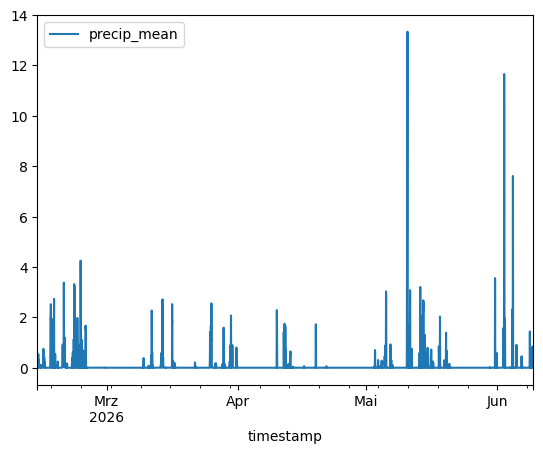

In [20]:
precip.plot()